## Task 2

Для начала работы вызовем все необходимые библиотеки:

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Откроем и просмотрим файл в csv формате, с которым будем работать:

In [5]:
df_test2 = pd.read_csv ('test2 - Лист1.csv')
df_test2.head (4)

,moderator,id_request,request_time,start_time,finish_time,team
0,165,159660,2020-09-24 7:01:16,2020-10-01 16:00:31,2020-10-01 16:02:02,retail
1,178,160116,2020-09-24 22:32:15,2020-10-01 13:21:42,2020-10-01 13:21:43,retail
2,187,160178,2020-09-25 2:58:13,2020-10-02 11:37:16,2020-10-02 11:41:56,wholesale
3,178,160306,2020-09-25 9:44:12,2020-10-02 7:23:09,2020-10-02 7:25:33,retail


In [6]:
df_test2.info() # посмотрим на типы данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35617 entries, 0 to 35616
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   moderator     35617 non-null  int64 
 1   id_request    35617 non-null  int64 
 2   request_time  35617 non-null  object
 3   start_time    35617 non-null  object
 4   finish_time   35617 non-null  object
 5   team          35617 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.6+ MB


In [7]:
# преобразуем столбцы времени в datetime
df_test2['request_time'] = pd.to_datetime(df_test2['request_time'])
df_test2['start_time'] = pd.to_datetime(df_test2['start_time'])
df_test2['finish_time'] = pd.to_datetime(df_test2['finish_time'])

In [8]:
df_test2.info() # перепроверяем повторно тип данных. теперь Всё хор!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35617 entries, 0 to 35616
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   moderator     35617 non-null  int64         
 1   id_request    35617 non-null  int64         
 2   request_time  35617 non-null  datetime64[ns]
 3   start_time    35617 non-null  datetime64[ns]
 4   finish_time   35617 non-null  datetime64[ns]
 5   team          35617 non-null  object        
dtypes: datetime64[ns](3), int64(2), object(1)
memory usage: 1.6+ MB


1. Как служба поддержки соответствует ожиданиям менеджмента? А именно, что в рамках каждого дня, среднее время от возникновения нового запроса пользователя до ответа должно быть 15 минут. Также плохо, если пользователи сервиса ждут ответа дольше 45 минут.

1.1 Как она работает сейчас?

In [10]:
df_test2[df_test2.team == 'wholesale'].shape[0] # на сколько запросов ответила команда опта

21592

In [11]:
df_test2[df_test2.team == 'retail'].shape[0] # на сколько запросов ответила команда розницы

14025

Видно, что команда опта обработала больше запросов. Посмотрим на временные показатели.

In [13]:
# Сколько по времени длится сессия в минутах
df_test2['session_time'] = (df_test2['finish_time']- df_test2['start_time']).dt.total_seconds() / 60 
# среднее время сессии
avg_session_time = round(df_test2['session_time'].mean(),0)

print(f"Average Session Time: {avg_session_time} mins")

Average Session Time: 2.0 mins


In [14]:
#  Сколько по времени длится ожидание ответа от службы поддержки?
df_test2['response_time_min'] = (df_test2['start_time'] - df_test2['request_time']).dt.total_seconds() / 60

# Среднее время ожидания ответа 
avg_waiting_time = round(df_test2['response_time_min'].mean(),0)

print(f"Average Waiting time: {avg_waiting_time} mins")

Average Waiting time: 2469.0 mins


In [15]:
# Количество запросов,  в которых час ожидания ответа превышает 45 мин
problem_requests = df_test2[df_test2['response_time_min'] > 45].shape[0]
print(f"Problem Requests: {problem_requests}")

Problem Requests: 27904


Анализируя DataFrame, в котором данные по  35617 запросам, которые обрабатывало две команды, можно сделать вывод, что команда розницы обработала 14025 запросов, а оптовая 21592. Ожидания менеджмента не соответствуют реальным показателям, т.к. среднее время получения ответа от службы поддержки составляет 2469 минуты (а это больше 41 часа). Вероятнее всего количество персонала не достаточно, чтобы покрыть такой объем запросов в установленные сроки (от 15 до 45 минут). Или команды не работают 24\7. 

2. Будет ли хорошим решением объединить команды? Сравним эффективность двух команд. 

In [18]:
team_eff = df_test2.groupby('team').agg(
    avg_response_time = ('response_time_min', 'mean'),
    total_requests = ('id_request', 'count')
)

print(team_eff)

           avg_response_time  total_requests
team                                        
retail            607.786440           14025
wholesale        3677.494648           21592


/var/folders/pv/kp8x25cs1xs8xy48_h44q2bw0000gp/T/ipykernel_18312/1519627072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_eff, x='team', y='total_requests', palette='Set2')


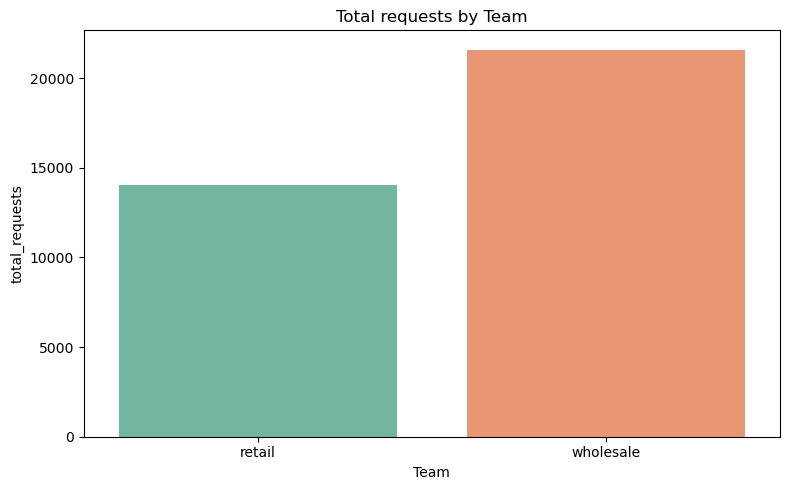

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=team_eff, x='team', y='total_requests', palette='Set2')

plt.title('Total requests by Team')
plt.xlabel('Team')
plt.ylabel('total_requests')
plt.tight_layout()
plt.show()

wholesale команда работает в разы медленнее, хотя обрабатывает больше запросов. Объединение может принести пользу, если сотрудники обладают универсальными знаниями в двух областях (розница и опт). Для этого найдем, в какой команде более слабые сотрудники.

3. На каких агентов следует обратить внимание для повышения качества обслуживания?

In [21]:
# Считаем среднее время ответов по каждому сотруднику и команду 
empl_stats = df_test2.groupby(['moderator', 'team']).agg(
    avg_response_time=('response_time_min', 'mean'),
    total_requests=('id_request', 'count')
).reset_index()

# Фильтр сотрудников по времени ответа  > 45 хв
slow_empl = empl_stats[empl_stats['avg_response_time'] > 45].sort_values(by='avg_response_time', ascending=False)

# Считаем распределение по командам слабых сотрудников
slow_counts = slow_empl['team'].value_counts().reset_index()
slow_counts.columns = ['team', 'slow_empl_count']

In [22]:
print(slow_counts.to_string(index=False))

     team  slow_empl_count
wholesale               23
   retail               21


Распределение практически равномерное. Эти 44 сотрудника снижают общую эффективность - на них и стоит обратить внимание. Возможно на них слишком большая нагрузка по сложным запросам или они недостаточно компетентны.

4. Стоит ли увеличить команду поддержки и на сколько?


In [24]:
# Группирую по сотрудникам и считаю количество выполненных запросов
empl_load = df_test2.groupby('moderator').agg(
    requests_done=('id_request', 'count'),
    avg_response_time=('response_time_min', 'mean')
)

# Сортирую по количеству выполненных запросов
empl_load = empl_load.sort_values(by='requests_done', ascending=False)

print(empl_load)


           requests_done  avg_response_time
moderator                                  
188                 3746        4058.972153
112                 1717        4382.390992
170                 1686        3883.557661
181                 1625        4692.149733
123                 1452        3762.907828
180                 1349        4579.584470
186                 1342         606.537121
102                 1321        3714.671625
103                 1313        3000.176085
117                 1251         454.777764
187                 1193        4372.228444
125                 1146        3620.503883
172                  946         591.040821
146                  909        3225.004730
135                  857         440.738001
153                  838        3169.710879
109                  827         745.485369
176                  803         611.762495
121                  799         690.440259
122                  767        3316.830574
149                  751        

Судя по выборке, распределение запросов между сотрудниками не равномерное. Перед тем как тратить деньги на расширение штата, лучше попробовать обучить\ переобучить имеющихся сотрудников. А так же проверить график сотрудников, анализируя пиковые часы - перераспределить по сменно работу службы поддержки

<Axes: xlabel='hour'>

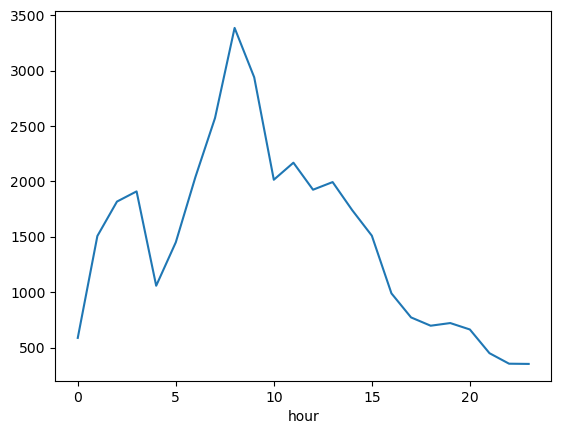

In [26]:
df_test2['hour'] = df_test2['request_time'].dt.hour
df_test2.groupby('hour')['id_request'].count().plot(kind='line')


В целом необходимо переобучить сотрудников и сделать несколько рабочих смен в пиковые часы работы.

In [28]:
MAX_date = df_test2['request_time'].max()
MIN_date = df_test2['request_time'].min()
num_agents = df_test2['moderator'].nunique()

print(f"MAX date: {MAX_date}")
print(f"MIN date: {MIN_date}")
print(f"Total empl: {num_agents}")


MAX date: 2020-12-31 22:11:17
MIN date: 2020-09-24 07:01:16
Total empl: 49


Данные собраны чуть больше чем за три месяца, количество сотрудников в группе поддержки 49, ними обработано запросов за этот период 35617. 
Предположим, команда будет работать в три смены, в каждой из них по 15 человек, стандартные 22 рабочих дня в месяц.

45x66 = 2970

35617/2970 = 12 запросов в среднем в день на каждого сотрудника или 792 запроса за три рабочих месяца, при средней равномерной нагрузке между всеми сотрудниками группы поддержки.